# imports

In [256]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [257]:
link_hist = '/Users/artemvorobchenko/Desktop/traiding_data/noHistory (2)/normalized-2026-01-02.csv'
link_profit = '/Users/artemvorobchenko/Desktop/traiding_data/noHistory (2)/profitable_trades_main.csv'

In [258]:
cols_noHistory = pd.read_csv(link_hist, nrows=1).columns

num_cols = [col for col in all_cols if 'symbol' not in col]

In [259]:
noHistory = pd.read_csv(link_hist, usecols=num_cols)
profit = pd.read_csv(link_profit)

# isnull stats
* дроп колонок, где пропуски составляют > 50%
* после заполним оставшиеся NaN предыдущими ненулевыми значениями (ffill)
* для колонок которые начинались с NaN, заполним следующими ненулевыми (bfill)

In [260]:
print(f'NaN: {round(noHistory.isna().sum().sum() / noHistory.size * 100, 2)} %')

#noHistory.isnull().mean() * 100

NaN: 19.31 %


In [261]:
noHistory_clear = noHistory.dropna(thresh=(len(noHistory) * 0.5), axis=1)
#noHistory_clear.columns[noHistory_clear.isnull().any()].tolist()

In [262]:
print(f'NaN: {round(noHistory_clear.isna().sum().sum() / noHistory_clear.size * 100, 2)} %')

NaN: 4.53 %


In [263]:
noHistory_clear = noHistory_clear.copy()

noHistory_clear.ffill(inplace=True)
noHistory_clear.bfill(inplace=True)

In [264]:
print(f'NaN: {noHistory_clear.isna().sum().sum() / noHistory_clear.size * 100}%')

NaN: 0.0%


# Train/valid/test

* 70% train
* 15% valid
* 15% test

* поиск уникальных индексов покупки (делается для того, чтобы при разбиении на train/valid/test одинаковые индексы не попали в разные выборки, и не произошла утечка), после оставим только индексы >= 15, чтобы мы могли учитывать полную историю в тензоре

* еще важный момент, расстояние между train/valid/test должны быть минимум в 15 объектов, иначе получится, что например в valid попадет кусок данных из train, для этого нам просто нужно прибавлять к концам интревалов наш window_size

In [265]:
profit = profit.sort_values("buy_row_idx").reset_index(drop=True)

In [266]:
unique_buy_idx = profit["buy_row_idx"].unique()
unique_buy_idx = unique_buy_idx[unique_buy_idx >= 15]
unique_buy_idx = sorted(unique_buy_idx)

In [267]:
n_states = len(unique_buy_idx)
window_size = 16

train_end_idx = int(n_states * 0.70)
valid_end_idx = int(n_states * 0.85)

train_states = unique_buy_idx[:train_end_idx]
valid_states = unique_buy_idx[train_end_idx + window_size : valid_end_idx]
test_states  = unique_buy_idx[valid_end_idx + window_size :]

# кол-во уникальных индексов, которые попадут train/valid/test
* так же посмотрим распределения CALL/PUT

In [268]:
print("Train states:", len(train_states))
print("Valid states:", len(valid_states))
print("Test states:", len(test_states))

Train states: 2702
Valid states: 563
Test states: 563


In [269]:
train_states_set = set(train_states)
valid_states_set = set(valid_states)
test_states_set  = set(test_states)

profit_train = profit[profit["buy_row_idx"].isin(train_states_set)].copy()
profit_valid = profit[profit["buy_row_idx"].isin(valid_states_set)].copy()
profit_test  = profit[profit["buy_row_idx"].isin(test_states_set)].copy()

In [270]:
profit.groupby("type")["buy_row_idx"].agg(["min", "max", "count"])

,min,max,count
type,,,
Temporal_CALL_1,10,4419,438898
Temporal_PUT_1,10,4418,302333


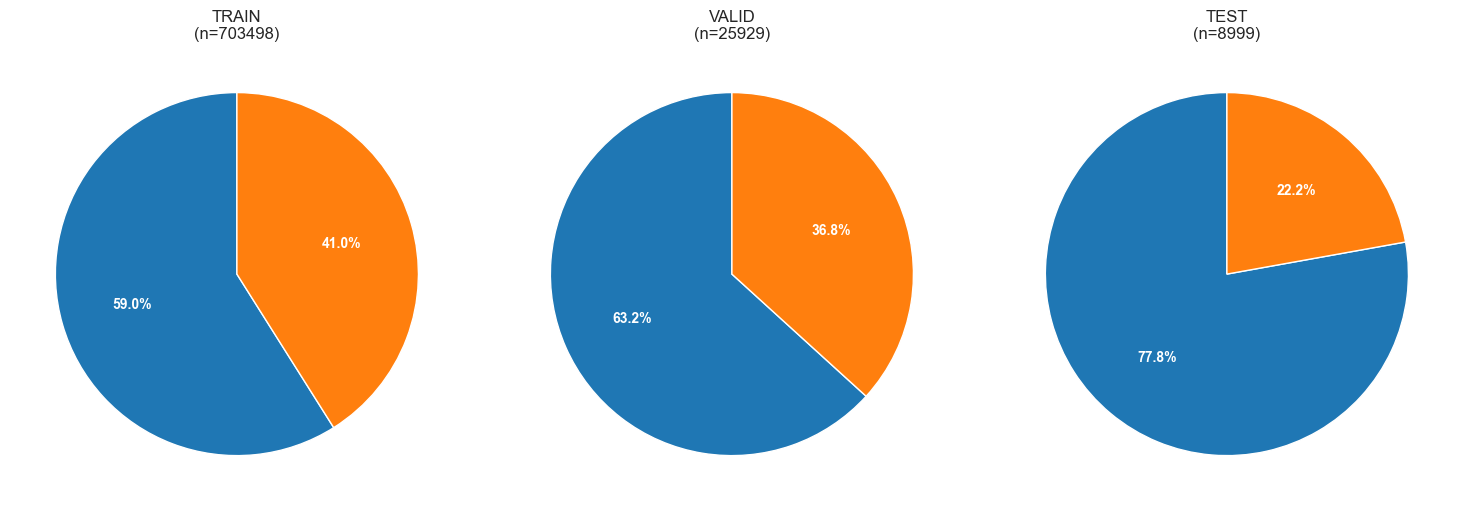

In [276]:
train_dist = profit_train["type"].value_counts()
valid_dist = profit_valid["type"].value_counts()
test_dist = profit_test["type"].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
distributions = [train_dist, valid_dist, test_dist]
titles = ['TRAIN', 'VALID', 'TEST']

for ax, dist, title in zip(axes, distributions, titles):
    wedges, texts, autotexts = ax.pie(dist,
                                       autopct='%1.1f%%',
                                       startangle=90,
                                       textprops={'fontsize': 10})
    ax.set_title(f'{title}\n(n={sum(dist)})')

    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

### не забыть в будущем чек кластера профит рэтио по put/call

# Функция создания окон
* берем 16 строк рынка и оборачиваем в тензор [samples , timesteps , features]


3828 уникальных индексов = 2702 + 563 + 563
на каждый индекс у нас приходится по временому срезу из 16 объектов

* 2702*16 = 43232
* 563*16  = 9008
* 563*16  = 9008

СУММА = 61248 уникальных строк для обучения энкодера


In [272]:
def build_tensor(shop_df, state_indices, window_size=16):
    samples = []
    used_states = []

    for t in state_indices:
        if t >= window_size - 1:
            seq = shop_df.iloc[t - window_size + 1 : t + 1].values
            samples.append(seq)
            used_states.append(t)

    X = np.stack(samples)

    return X, np.array(used_states)

In [273]:
X_train, train_states_used = build_tensor(noHistory_clear, train_states)
X_valid, valid_states_used = build_tensor(noHistory_clear, valid_states)
X_test, test_states_used = build_tensor(noHistory_clear, test_states)

In [275]:
X_valid

array([[[6.8090e+02, 2.9000e+01, 8.3100e+00, ..., 4.0000e-03,
         2.6610e+01, 6.7400e+02],
        [6.8089e+02, 2.9000e+01, 8.3100e+00, ..., 4.0000e-03,
         2.6610e+01, 6.7400e+02],
        [6.8094e+02, 2.9000e+01, 8.3100e+00, ..., 4.0000e-03,
         2.6610e+01, 6.7400e+02],
        ...,
        [6.8081e+02, 2.9000e+01, 8.3100e+00, ..., 4.0000e-03,
         2.6610e+01, 6.7400e+02],
        [6.8082e+02, 2.9000e+01, 8.3100e+00, ..., 4.0000e-03,
         2.6610e+01, 6.7400e+02],
        [6.8085e+02, 2.9000e+01, 8.3100e+00, ..., 4.0000e-03,
         2.6610e+01, 6.7400e+02]],

       [[6.8089e+02, 2.9000e+01, 8.3100e+00, ..., 4.0000e-03,
         2.6610e+01, 6.7400e+02],
        [6.8094e+02, 2.9000e+01, 8.3100e+00, ..., 4.0000e-03,
         2.6610e+01, 6.7400e+02],
        [6.8081e+02, 2.9000e+01, 8.3100e+00, ..., 4.0000e-03,
         2.6610e+01, 6.7400e+02],
        ...,
        [6.8082e+02, 2.9000e+01, 8.3100e+00, ..., 4.0000e-03,
         2.6610e+01, 6.7400e+02],
        [6.8